In [112]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib . pyplot as plt
 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
df=sns.load_dataset('tips')
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [113]:
df.tail()

,total_bill,tip,sex,smoker,day,time,size
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2
243,18.78,3.00,Female,No,Thur,Dinner,2


In [114]:
df.shape

(244, 7)

In [115]:
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [116]:
df.describe

<bound method NDFrame.describe of      total_bill   tip     sex smoker   day    time  size
0         16.99  1.01  Female     No   Sun  Dinner     2
1         10.34  1.66    Male     No   Sun  Dinner     3
2         21.01  3.50    Male     No   Sun  Dinner     3
3         23.68  3.31    Male     No   Sun  Dinner     2
4         24.59  3.61  Female     No   Sun  Dinner     4
..          ...   ...     ...    ...   ...     ...   ...
239       29.03  5.92    Male     No   Sat  Dinner     3
240       27.18  2.00  Female    Yes   Sat  Dinner     2
241       22.67  2.00    Male    Yes   Sat  Dinner     2
242       17.82  1.75    Male     No   Sat  Dinner     2
243       18.78  3.00  Female     No  Thur  Dinner     2

[244 rows x 7 columns]>

In [117]:
df.isnull().sum()

total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64

In [118]:
# x= df.drop('tip',axis=1)
# y= df['tip']
# print(df)

<Axes: >

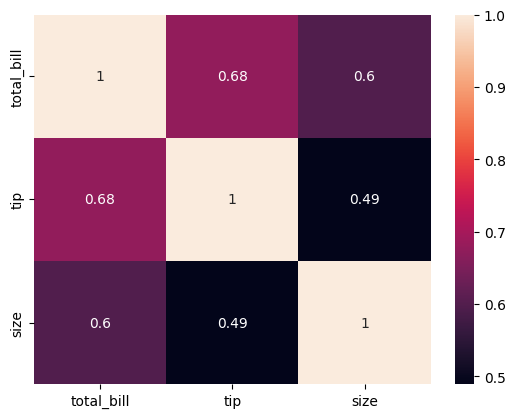

In [119]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [120]:
cat_cols= ['sex','smoker','day','time']
num_cols= ['total_bill','size']
features= ['total_bill','size','sex','smoker','day','time']
x=df[features]
y=df['tip']


In [121]:
preprocessor=ColumnTransformer([
    ('cat',OneHotEncoder(drop='first'),cat_cols),
    ('num',StandardScaler(),num_cols)
])
pipeline=Pipeline([
    ('preprocessor',preprocessor),
    ('model',LinearRegression())
])

In [122]:
x_train, x_test, y_train, y_test= train_test_split(
    x,y, test_size=0.2,random_state=42
)

In [123]:
pipeline.fit (x_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [124]:
y_pred= pipeline.predict(x_test)
print("R2score:", r2_score(y_test,y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test,y_pred)))

R2score: 0.43730181943482505
RMSE: 0.838663580790063


In [125]:
import pickle
pickle.dump(pipeline, open('tips_model.pkl','wb'))